# Model Training Process Analysis

Two types of model architectures were trained on the data with 3 differenet data balancing techniques:
- none
- sampling
- weighted entrophy

Below there is an overview of training process for performed experiments.
batch size = 10
epochs = 10

In [1]:
import os
import json
import matplotlib.pyplot as plt
import pandas as pd

Loading training data from /outputs directory, each folder corresponds to one experiment.

In [2]:
OUTPUT_DIR = "../outputs"

experiments = {}

for exp_name in os.listdir(OUTPUT_DIR):
    exp_path = os.path.join(OUTPUT_DIR, exp_name)
    
    history_path = os.path.join(exp_path, "training_history.json")
    
    if os.path.exists(history_path):
        with open(history_path) as f:
            experiments[exp_name] = json.load(f)

print("Loaded experiments:")
for name in experiments:
    print("-", name)

Loaded experiments:
- resnet_binary_none_20260426_1207
- resnet_binary_sampler_20260427_0854
- vit_binary_none_20260426_1715
- vit_binary_sampler_20260429_1214


Extracting the loss from training hstory for each experiment and plotting it alongside with other experiments.

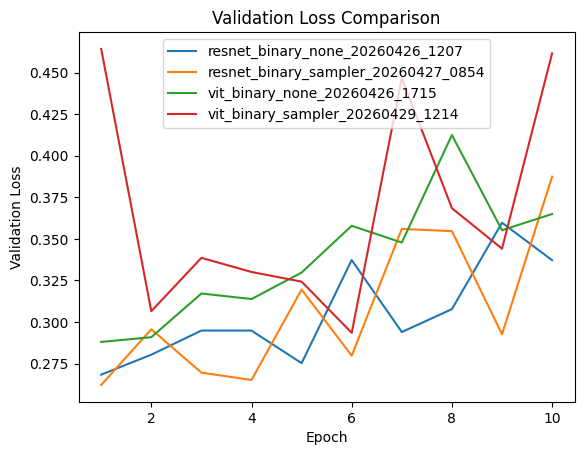

In [3]:
plt.figure()

for name, history in experiments.items():
    epochs = range(1, len(history["val_loss"]) + 1)
    plt.plot(epochs, history["val_loss"], label=name)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison")
plt.legend()
plt.show()

Extracting the accuracy from training hstory for each experiment and plotting it alongside with other experiments.

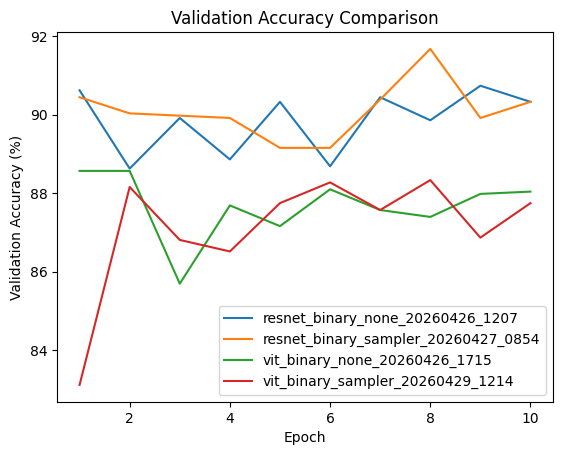

In [4]:
plt.figure()

for name, history in experiments.items():
    epochs = range(1, len(history["val_acc"]) + 1)
    plt.plot(epochs, history["val_acc"], label=name)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Validation Accuracy Comparison")
plt.legend()
plt.show()

In [5]:
results = []

for name, history in experiments.items():
    best_acc = max(history["val_acc"])
    best_epoch = history["val_acc"].index(best_acc) + 1
    
    results.append({
        "experiment": name,
        "best_acc": best_acc,
        "best_epoch": best_epoch
    })

df_results = pd.DataFrame(results)
df_results

,experiment,best_acc,best_epoch
0,resnet_binary_none_20260426_1207,90.738570,9
1,resnet_binary_sampler_20260427_0854,91.676436,8
2,vit_binary_none_20260426_1715,88.569754,1
3,vit_binary_sampler_20260429_1214,88.335287,8
